In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# --!--------------------------------------------------------------------------
# --! prepare a dataset

# --! define known data properties
timeseries_len  = 200
timestep        = 0.001
dataset_dir     = 'cavity/train_10Hz_24Hz_sum'
x_len           = 200

# --! read data from files
data_train = utils.read_datafile(f'{dataset_dir}/train1', timeseries_len)
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)

# --! data channels are expected to contain:
# --! 1. displacement
x_dims_n = 1

# --! compile dataset parameters
data_table = [
    ( 'dataset',           'batches',        'timeseries length',          'channels'),
    ('--------',           '-------',        '-----------------',          '--------'),
    (   'train', data_train.shape[0], data_train.shape[1], data_train.shape[2]),
    (   'valid', data_valid.shape[0], data_valid.shape[1], data_valid.shape[2]),
    (    'test',  data_test.shape[0],  data_test.shape[1],  data_test.shape[2]) ]

# --! print dataset parameters
print('inf >> dataset parameters:')
print('')
for row in data_table:
    print(f'{row[0]:>8} {row[1]:>8} {row[2]:>18} {row[3]:>8}')

inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1


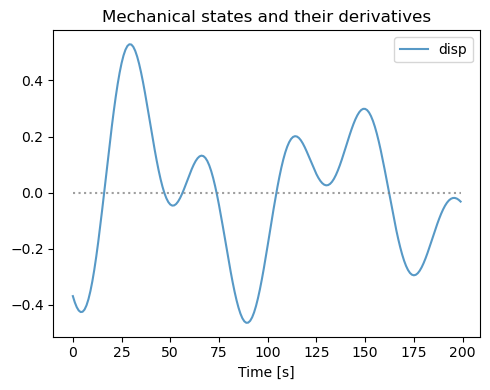

In [3]:
data_i = 4
data_viz = data_train[data_i]
t_viz = torch.linspace(0., timestep*timeseries_len, timeseries_len)
zero_viz = torch.zeros_like(t_viz)

plt.figure(figsize=(5, 4))
plt.title('Mechanical states and their derivatives')
plt.plot(data_viz[:, 0], color='tab:blue', alpha=0.75, label='disp')
plt.plot(zero_viz, color='tab:gray', linestyle='dotted', alpha=0.75)
plt.legend()
plt.xlabel('Time [s]')
plt.tight_layout()
plt.show()

In [4]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

model = care.detune()

inf >> Number of data files for training : 6
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6


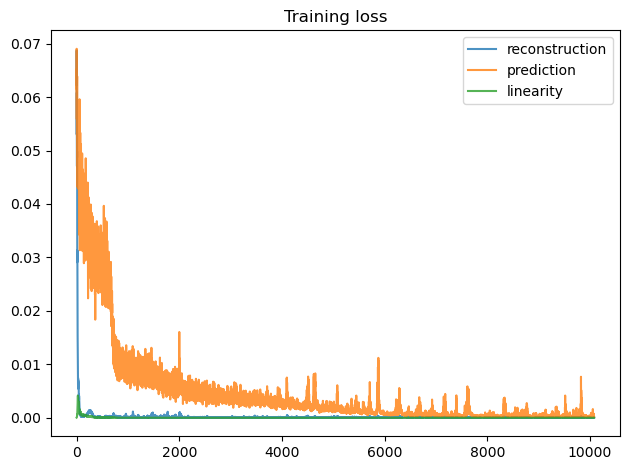

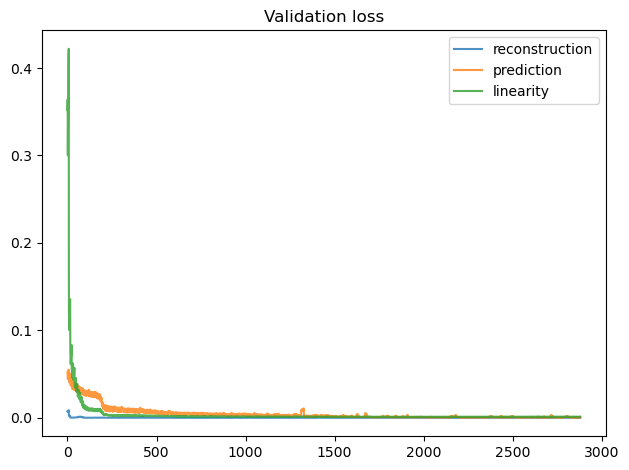

inf >> reconstruction loss in training is 2.061626e-04
inf >> prediction loss in training is 4.770195e-03
inf >> linearity loss in training is 3.959649e-05


In [5]:
# --!--------------------------------------------------------------------------
# --! training and validation of the global Koopman operator

# --! we train the global operator first, so freeze the local one
utils.freeze_module(model.funs_dyn_enc)
utils.freeze_module(model.funs_dyn)
utils.unfreeze_module(model.timeseries_dyn)

bat_sz = 128

# --! specify optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001,
    weight_decay=1e-8)

# --! empty arrays to gather statistics
loss_train_recon = []
loss_train_pred  = []
loss_train_lin   = []

loss_valid_recon = []
loss_valid_pred  = []
loss_valid_lin   = []

# --! training duration
datafiles_train_n = 6
epochs_n          = 60
print(f"inf >> Number of data files for training : {datafiles_train_n}")

# --! prepare validation dataset
dataset_valid = torch.utils.data.TensorDataset(data_valid)

for datafile_train in range(datafiles_train_n):
    print(f"inf >> processing training file number {datafile_train + 1}")

    # --! make training datasets and loaders
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=bat_sz, shuffle=True)

    # --! train
    for epoch in range(epochs_n):

        # --! train neural networks
        for this, data in enumerate(dataloader_train):
            x = data[0][:, :x_len, :1]

            optimizer.zero_grad()

            # --! fit a model to training data
            loss, loss_ae, loss_pred, loss_lin = model.fit(x, global_only=True)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                loss_train_recon.append(loss_ae)
                loss_train_pred.append(loss_pred)
                loss_train_lin.append(loss_lin)

        # --! validate results
        with torch.no_grad():
            dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=bat_sz, shuffle=False)
            for data in dataloader_valid:
                x  = data[0][:, :x_len, :1] # take only displacement

                # --! validate prediction
                funs, funs_pred, timeseries_recon, timeseries_pred, timeseries_dyn_mat, funs_dyn_mat = model(x, global_only=True)
                loss_valid_recon.append(torch.mean((x - timeseries_recon)**2))
                loss_valid_pred.append(torch.mean((x - timeseries_pred)**2))
                loss_valid_lin.append(torch.mean((funs - funs_pred)**2))

# --! display training statistics
with torch.no_grad():
    plt.figure()
    plt.title('Training loss')
    plt.plot(loss_train_recon, alpha=0.8, label='reconstruction')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.title('Validation loss')
    plt.plot(loss_valid_recon, alpha=0.8, label='reconstruction')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    loss_train_recon_mean = np.mean(loss_train_recon)
    loss_train_pred_mean = np.mean(loss_train_pred)
    loss_train_lin_mean = np.mean(loss_train_lin)
    print(f'inf >> reconstruction loss in training is {loss_train_recon_mean:e}')
    print(f'inf >> prediction loss in training is {loss_train_pred_mean:e}')
    print(f'inf >> linearity loss in training is {loss_train_lin_mean:e}')


In [6]:
with torch.no_grad():
    # --! make validation datasets and loaders
    dataset_test = torch.utils.data.TensorDataset(data_test)
    dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=bat_sz, shuffle=False)

    loss_test_recon = []
    loss_test_pred = []

    for data in dataloader_test:
        x  = data[0][:, :x_len, :x_dims_n]

        funs, funs_pred, timeseries_recon, timeseries_pred, timeseries_dyn_mat, funs_dyn_mat = model(x, global_only=True)
        loss_test_recon.append(torch.mean((x - timeseries_recon)**2))
        loss_test_pred.append(torch.mean((x - timeseries_pred)**2))

    loss_test_recon_mean = np.mean(loss_test_recon)
    loss_test_pred_mean = np.mean(loss_test_pred)
    print(f'inf >> reconstruction loss in test is {loss_test_recon_mean:e}') # 1.642286e-05
    print(f'inf >> prediction loss in test is {loss_test_pred_mean:e}') # 4.375873e-04

inf >> reconstruction loss in test is 1.642286e-05
inf >> prediction loss in test is 4.375873e-04


tensor([[ 0.7827+0.5721j,  0.7827-0.5721j,  0.0523+0.9613j,  0.0523-0.9613j,
         -0.3496+0.0000j]])


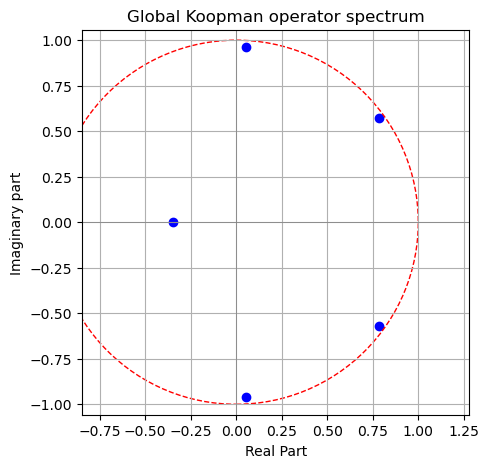

In [7]:
with torch.no_grad():
    eigvals = torch.linalg.eigvals(timeseries_dyn_mat)
    print(eigvals)

    plt.figure(figsize=(5, 5))
    plt.scatter(eigvals.real, eigvals.imag, c='blue')
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.axvline(0, color='gray', linewidth=0.5)
    circle = plt.Circle((0, 0), 1, color='r', fill=False, linestyle='--')
    plt.gca().add_artist(circle)
    plt.title("Global Koopman operator spectrum")
    plt.xlabel("Real Part")
    plt.ylabel("Imaginary part")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

tensor([[[ 0.4621, -0.4552,  0.8945, -0.0729,  0.6663],
         [ 0.7453,  0.2645, -0.2738, -0.4253, -0.3115],
         [-0.3485, -0.1189, -0.0099,  1.0368, -0.4846],
         [-0.1140, -0.8696, -0.2158,  0.5486, -0.2958],
         [-0.5367, -0.0700,  0.2448, -0.1677,  0.0549]]], requires_grad=True)
tensor([[[0.1600, 0.2838, 0.1809, 0.1351, 0.2402],
         [0.1571, 0.2131, 0.1504, 0.1411, 0.3383],
         [0.1312, 0.1643, 0.2092, 0.1939, 0.3014],
         [0.1486, 0.2517, 0.1663, 0.1477, 0.2856],
         [0.1789, 0.2302, 0.1576, 0.1546, 0.2786]]])


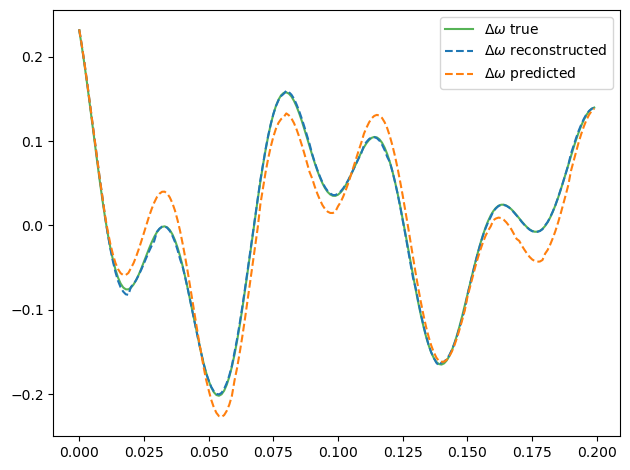

In [8]:
with torch.no_grad():
    data_i  = 123
    data    = data_test[data_i]

    timeseries = torch.unsqueeze(data[:x_len, :1], dim=0)
    funs, funs_pred, timeseries_recon, timeseries_pred, timeseries_dyn_mat, funs_dyn_mat = model(
        timeseries,
        global_only=True,
        alpha=0.25)

    print(timeseries_dyn_mat)
    print(funs_dyn_mat)

    timeseries = torch.squeeze(timeseries, dim=0)
    timeseries_recon = torch.squeeze(timeseries_recon, dim=0)
    timeseries_pred = torch.squeeze(timeseries_pred, dim=0)

    t = np.arange(0., x_len*timestep, timestep)

    plt.figure()
    plt.plot(t, timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
    plt.plot(t, timeseries_recon[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ reconstructed')
    plt.plot(t, timeseries_pred[:, 0], alpha=1, color='tab:orange', linestyle='dashed', label='$\\Delta \\omega$ predicted')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
# --!--------------------------------------------------------------------------
# --! training and validation of the local Koopman operator

# stop for now
print(tata.shape)

bat_sz = 128

# --! specify optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-8)

# --! empty arrays to gather statistics
loss_train_recon = []
loss_train_pred  = []
loss_train_lin   = []

loss_valid_recon = []
loss_valid_pred  = []
loss_valid_lin   = []

# --! training duration
datafiles_train_n = 6
epochs_n          = 60
print(f"inf >> Number of data files for training : {datafiles_train_n}")

# --! prepare validation dataset
dataset_valid = torch.utils.data.TensorDataset(data_valid)

for datafile_train in range(datafiles_train_n):
    print(f"inf >> processing training file number {datafile_train + 1}")

    # --! make training datasets and loaders
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=bat_sz, shuffle=True)

    # --! train
    for epoch in range(epochs_n):

        # --! train neural networks
        for this, data in enumerate(dataloader_train):
            x = data[0][:, :x_len, :1]

            optimizer.zero_grad()

            # --! fit a model to training data
            loss, loss_ae, loss_pred, loss_lin = model.fit(x, global_only=False, alpha=0.2)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                loss_train_recon.append(loss_ae)
                loss_train_pred.append(loss_pred)
                loss_train_lin.append(loss_lin)

        # --! validate results
        with torch.no_grad():
            dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=bat_sz, shuffle=False)
            for data in dataloader_valid:
                x  = data[0][:, :x_len, :1] # take only displacement

                # --! validate prediction
                funs, funs_pred, timeseries_recon, timeseries_pred, timeseries_dyn_mat, funs_dyn_mat = model(
                    x, global_only=False, alpha=0.2)
                loss_valid_recon.append(torch.mean((x - timeseries_recon)**2))
                loss_valid_pred.append(torch.mean((x - timeseries_pred)**2))
                loss_valid_lin.append(torch.mean((funs - funs_pred)**2))

# --! display training statistics
with torch.no_grad():
    plt.figure()
    plt.title('Training loss')
    plt.plot(loss_train_recon, alpha=0.8, label='reconstruction')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.title('Validation loss')
    plt.plot(loss_valid_recon, alpha=0.8, label='reconstruction')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    loss_train_recon_mean = np.mean(loss_train_recon)
    loss_train_pred_mean = np.mean(loss_train_pred)
    loss_train_lin_mean = np.mean(loss_train_lin)
    print(f'inf >> reconstruction loss in training is {loss_train_recon_mean:e}')
    print(f'inf >> prediction loss in training is {loss_train_pred_mean:e}')
    print(f'inf >> linearity loss in training is {loss_train_lin_mean:e}')


NameError: name 'tata' is not defined

In [ ]:
eval_ts_len       = 200
eval_timestep     = 0.001
eval_dataset_dir  = 'cavity/eval_10Hz_24Hz'

eval_data = utils.read_datafile(f'{eval_dataset_dir}/eval1', eval_ts_len)

with torch.no_grad():
    data = torch.split(eval_data, 1, dim=0)
    for datum in data:
        outs = model(datum, global_only=True, alpha=0.27)

        print(outs[4])
        print(outs[5])

        timeseries = torch.squeeze(datum, dim=0)
        timeseries_recon = torch.squeeze(outs[2], dim=0)
        timeseries_pred = torch.squeeze(outs[3], dim=0)

        t = np.arange(0., eval_ts_len*eval_timestep, eval_timestep)

        plt.figure()
        plt.plot(t, timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
        plt.plot(t, timeseries_recon[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ reconstructed')
        plt.plot(t, timeseries_pred[:, 0], alpha=1, color='tab:orange', linestyle='dotted', label='$\\Delta \\omega$ predicted')
        plt.legend()
        plt.tight_layout()
        plt.show()